# Modeling HUPA0003 using rapid acting insulin and carb_input as exogenous variables 

## Get data and visualize it 

In [241]:
import pandas  as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [242]:
data = pd.read_csv('../Data/Preprocessed/HUPA0005P.csv', sep=';')[:2290]
data['time'] = pd.to_datetime(data['time'])

As portions of carbs are equivalent to 10g we convert it back into simple grams again in order to measure ICR 

In [243]:
data['carb_input'] = data['carb_input'] * 10 

Visualize it 

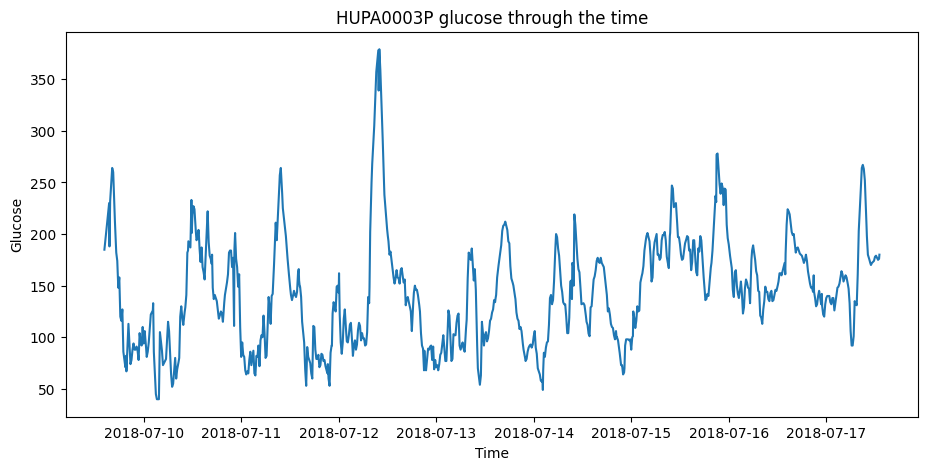

In [244]:
figure, ax = plt.subplots(1,1, figsize=(11, 5))
ax.plot(data['time'], data['glucose'])
ax.set(title='HUPA0003P glucose through the time', xlabel='Time', ylabel='Glucose')
plt.show()

## Insulin to Carb Ratio (ICR)

The ICR represents the number of grams of carbohydrate that 1 unit of rapid-acting insulin will cover. This ratio is highly individualized and varies from person to person.

Formula:
$
ICR = \text{Grams of Carbohydrate Eaten} / \text{Units of Rapid-Acting Insulin Taken}
$

Key Points:
- **Individual variation**: Each person has a unique ICR that may vary throughout the day
- **Clinical importance**: Proper ICR calculation is crucial for effective diabetes management
- **Monitoring**: Regular blood glucose monitoring helps adjust and validate ICR values

This ratio is fundamental for determining insulin dosing for meals and managing postprandial glucose levels.

In [245]:
import seaborn as sns

In [246]:
data.query('carb_input != 0 & bolus_volume_delivered != 0')

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
15,2018-07-09 15:35:00,188.000000,9.37970,84.880952,34.0,0.075000,1.9,10.0
92,2018-07-09 22:00:00,88.000000,6.73633,85.037879,8.0,0.075000,1.7,20.0
211,2018-07-10 07:55:00,66.666667,7.33322,90.716129,10.0,0.079167,1.3,15.0
285,2018-07-10 14:05:00,177.666667,8.35646,99.238095,44.0,0.075000,2.4,20.0
354,2018-07-10 19:50:00,133.666667,4.26350,96.364104,0.0,0.062500,0.6,5.0
383,2018-07-10 22:15:00,111.000000,4.26350,95.156195,0.0,0.075000,1.4,10.0
389,2018-07-10 22:45:00,176.000000,4.26350,94.906283,0.0,0.075000,1.8,20.0
506,2018-07-11 08:30:00,211.000000,4.26350,90.032994,0.0,0.079167,2.4,20.0
541,2018-07-11 11:25:00,176.000000,4.26350,88.575173,0.0,0.045833,1.1,10.0
579,2018-07-11 14:35:00,145.666667,4.26350,86.992395,0.0,0.075000,4.2,35.0


In [247]:
indexes = data.query('carb_input != 0 & bolus_volume_delivered != 0').index

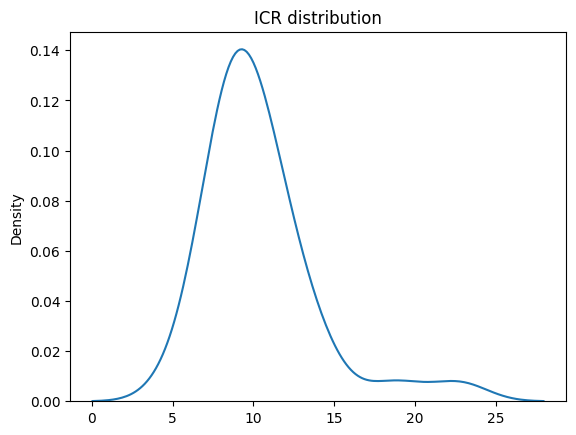

In [248]:
icr = data.loc[indexes]['carb_input'] / data.loc[indexes]['bolus_volume_delivered']
sns.kdeplot(icr)
plt.title('ICR distribution')
plt.show()

Now, let's add ICR as a dataset column

In [249]:
def get_ICR(x):
    carbs = x['carb_input']
    insulin = x['bolus_volume_delivered']
    if carbs == 0:
        return 0 
    elif insulin == 0:
        return 0
    else:
        return carbs/insulin

In [250]:
data['ICR'] = data.apply(get_ICR, axis=1)

In [251]:
data[data['ICR'] != 0]

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,ICR
15,2018-07-09 15:35:00,188.000000,9.37970,84.880952,34.0,0.075000,1.9,10.0,5.263158
92,2018-07-09 22:00:00,88.000000,6.73633,85.037879,8.0,0.075000,1.7,20.0,11.764706
211,2018-07-10 07:55:00,66.666667,7.33322,90.716129,10.0,0.079167,1.3,15.0,11.538462
285,2018-07-10 14:05:00,177.666667,8.35646,99.238095,44.0,0.075000,2.4,20.0,8.333333
354,2018-07-10 19:50:00,133.666667,4.26350,96.364104,0.0,0.062500,0.6,5.0,8.333333
383,2018-07-10 22:15:00,111.000000,4.26350,95.156195,0.0,0.075000,1.4,10.0,7.142857
389,2018-07-10 22:45:00,176.000000,4.26350,94.906283,0.0,0.075000,1.8,20.0,11.111111
506,2018-07-11 08:30:00,211.000000,4.26350,90.032994,0.0,0.079167,2.4,20.0,8.333333
541,2018-07-11 11:25:00,176.000000,4.26350,88.575173,0.0,0.045833,1.1,10.0,9.090909
579,2018-07-11 14:35:00,145.666667,4.26350,86.992395,0.0,0.075000,4.2,35.0,8.333333


Let's visualize glucose, carbs, ICR and rapid-acting insulin at the same time, in order to visualize it properly, we normalize it 

In [252]:
def get_ticks(size_window, time_axis):
    index_ticks = []
    j = 0 
    i = 0
    while j != 288: ## A day contains 288 samples
        i = j
        index_ticks.append(time_axis.index[i])
        j += size_window
    ticks = time_axis[index_ticks]
    label_ticks = ticks.dt.strftime('%Y/%m/%d %H:%M')
    return ticks, label_ticks

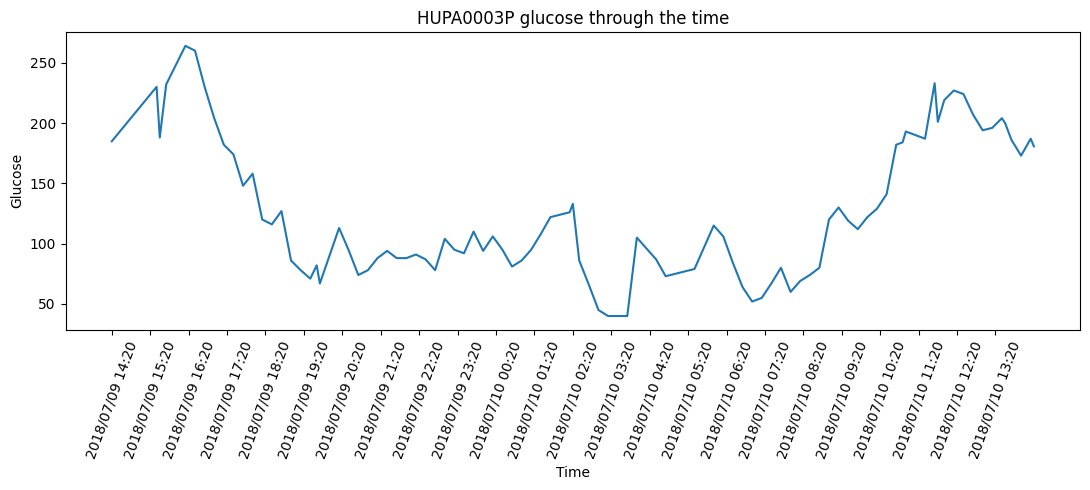

In [253]:
one_day = data[:289]
figure, ax = plt.subplots(1,1, figsize=(11, 5))
ticks, ticks_labels = get_ticks(12, data['time'])
ax.plot(one_day['time'], one_day['glucose'])
ax.set(title='HUPA0003P glucose through the time', xlabel='Time', ylabel='Glucose')
ax.set_xticks(ticks)  
ax.set_xticklabels(ticks_labels, rotation=70)
plt.tight_layout()
plt.show()

In [254]:
def normalize(data):
    mean = data.mean()
    std = data.std()
    if std == 0:
        return data - mean
    return (data - mean) / std

In [255]:
def normalize_df(df):
    return df.select_dtypes(include='float64').apply(normalize, axis=0)

## All variables together 

In [256]:
def plot_variables_normalized(df):
    ## Firstly normalize it and get time_axis 
    time_axis = df['time']
    normalized_df = normalize_df(df)
    ## Now plot it
    _, ax = plt.subplots(1,1, figsize=(11, 7))
    ticks, ticks_labels = get_ticks(12, time_axis)
    for c in normalized_df.columns:
        ax.plot(time_axis, normalized_df[c], label=f'{c}')
    ax.set(title='The behaivor of all variables along one day', xlabel='Time', ylabel='Variables')
    ax.set_xticks(ticks)  
    ax.set_xticklabels(ticks_labels, rotation=70)
    plt.tight_layout()
    plt.legend()
    plt.show()

Firstly, plot all variables 

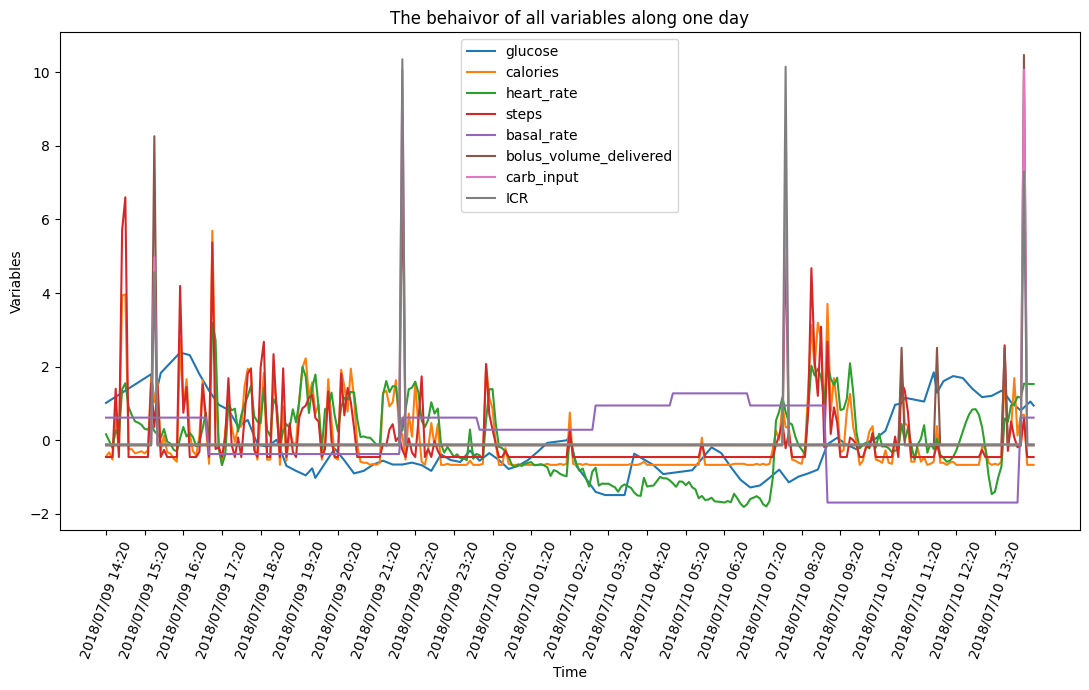

In [257]:
plot_variables_normalized(one_day)

Now just glucose, rapid-acting insulin and steps 

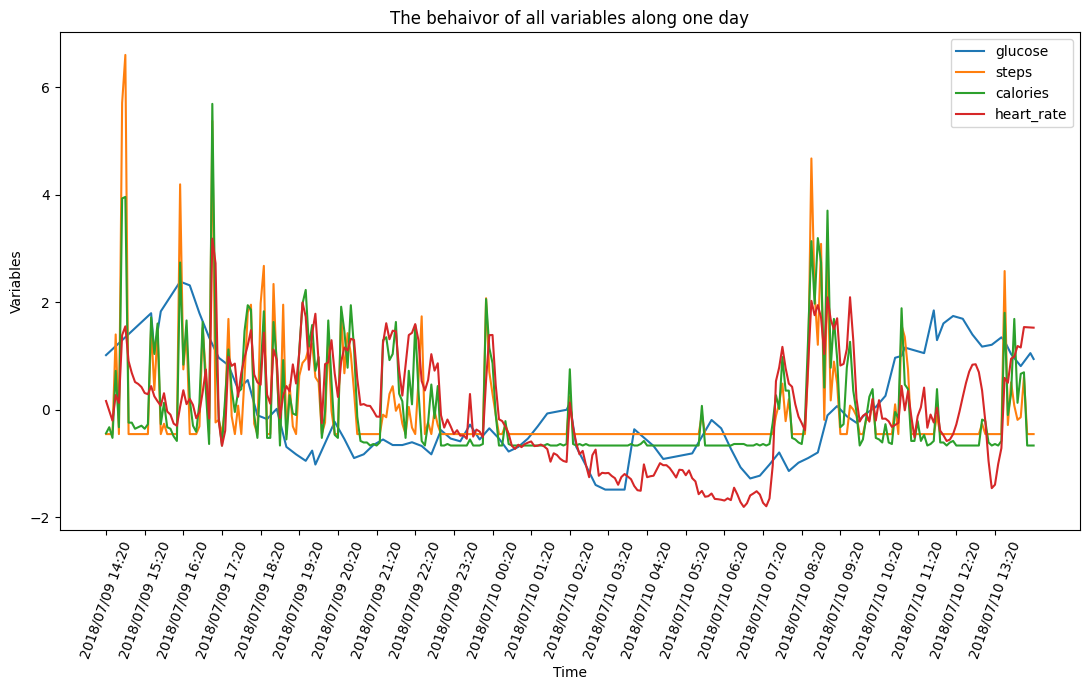

In [258]:
plot_variables_normalized(one_day[['time', 'glucose', 'steps', 'calories', 'heart_rate']])

As we could see above apparently, exists a correspondence between steps and glucose, in order to explore it, let's plot another day 

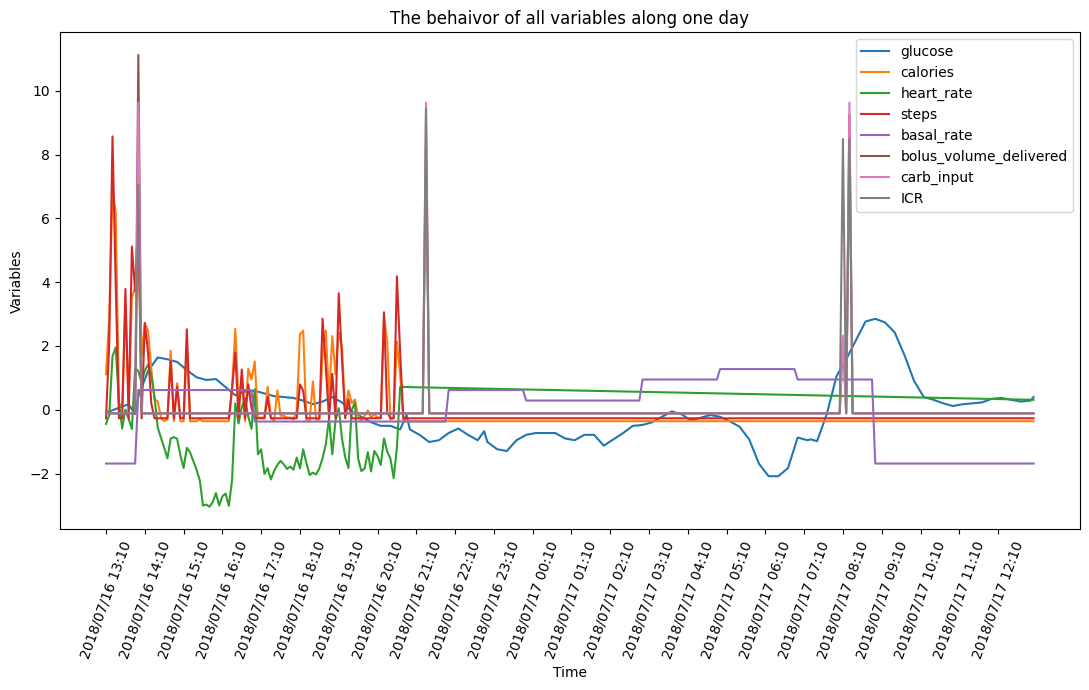

In [259]:
last_day = data[-288:]
plot_variables_normalized(last_day)

## Correlations 

In [260]:
data

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,ICR
0,2018-07-09 14:20:00,184.838710,4.94566,83.906977,0.0,0.075000,0.0,0.0,0.0
1,2018-07-09 14:25:00,188.064516,5.28674,81.858156,0.0,0.075000,0.0,0.0,0.0
2,2018-07-09 14:30:00,191.290323,4.68985,79.834646,0.0,0.075000,0.0,0.0,0.0
3,2018-07-09 14:35:00,194.516129,8.44173,85.146552,77.0,0.075000,0.0,0.0,0.0
4,2018-07-09 14:40:00,197.741935,5.28674,83.511811,0.0,0.075000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2285,2018-07-17 12:45:00,175.000000,4.26350,92.772166,0.0,0.045833,0.0,0.0,0.0
2286,2018-07-17 12:50:00,175.333333,4.26350,92.759782,0.0,0.045833,0.0,0.0,0.0
2287,2018-07-17 12:55:00,175.666667,4.26350,92.747397,0.0,0.045833,0.0,0.0,0.0
2288,2018-07-17 13:00:00,176.000000,4.26350,92.735013,0.0,0.045833,0.0,0.0,0.0


In [261]:
corr_matrix = data.corr(numeric_only=True)

In [262]:
corr_matrix['glucose']

glucose                   1.000000
calories                  0.073090
heart_rate                0.126966
steps                     0.008091
basal_rate               -0.176586
bolus_volume_delivered    0.065120
carb_input                0.029721
ICR                       0.015802
Name: glucose, dtype: float64

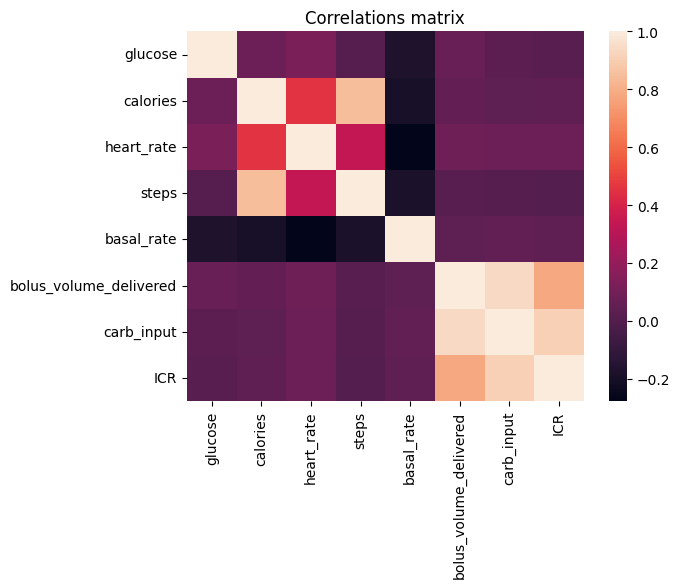

In [263]:
sns.heatmap(corr_matrix)
plt.title('Correlations matrix')
plt.show()

## Define train and test size 

In [264]:
horizon = 12
train, test = data[:-horizon], data[-horizon:]

In [265]:
exog_variable = 'heart_rate'

## AIC and BIC criteria 

Now, we generate all combinations (p=4,q=4) to apply both AIC and BIC

In [266]:
from itertools import product

range_start = 0
range_end = 5
combinations = list(product(range(range_start, range_end), repeat=2))

In [267]:
combinations

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

In [268]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_ARIMA(endog: pd. Series, exog: pd.Series, order_list: list, d: int) -> pd.DataFrame:
    results = {}
    scaler_glucose = StandardScaler()
    scaler_exog = StandardScaler()
    endog = scaler_glucose.fit_transform(endog.values.reshape(-1,1))
    exog = scaler_exog.fit_transform(exog.values.reshape(-1,1))

    for order in order_list:
        print(order)
        try:
            model = SARIMAX(endog, exog, order=(order [0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            print(f'Mistake during {order}')
            continue
        aic = model.aic
        results[order] = aic

    return sorted(results.items(), key=lambda x: x[1])[0][0]


In [269]:
best_order = optimize_ARIMA(endog=train['glucose'], exog=train[exog_variable], order_list=combinations, d=0)

(0, 0)
(0, 1)
(0, 2)


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 3)


...

/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 3)


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 4)


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Residual analysis 

In [270]:
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np 

In [271]:
scaler_endog = StandardScaler()
scaler_exog = StandardScaler()
endog = scaler_endog.fit_transform(train['glucose'].values.reshape(-1,1))
exog = scaler_exog.fit_transform(train[exog_variable].values.reshape(-1,1))

In [272]:
best_model = SARIMAX(endog=endog, exog=exog, order=(best_order[0],0,best_order[1]), simple_differencing=False).fit(disp=False)
residuals = best_model.resid
predictions_train = best_model.fittedvalues

/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


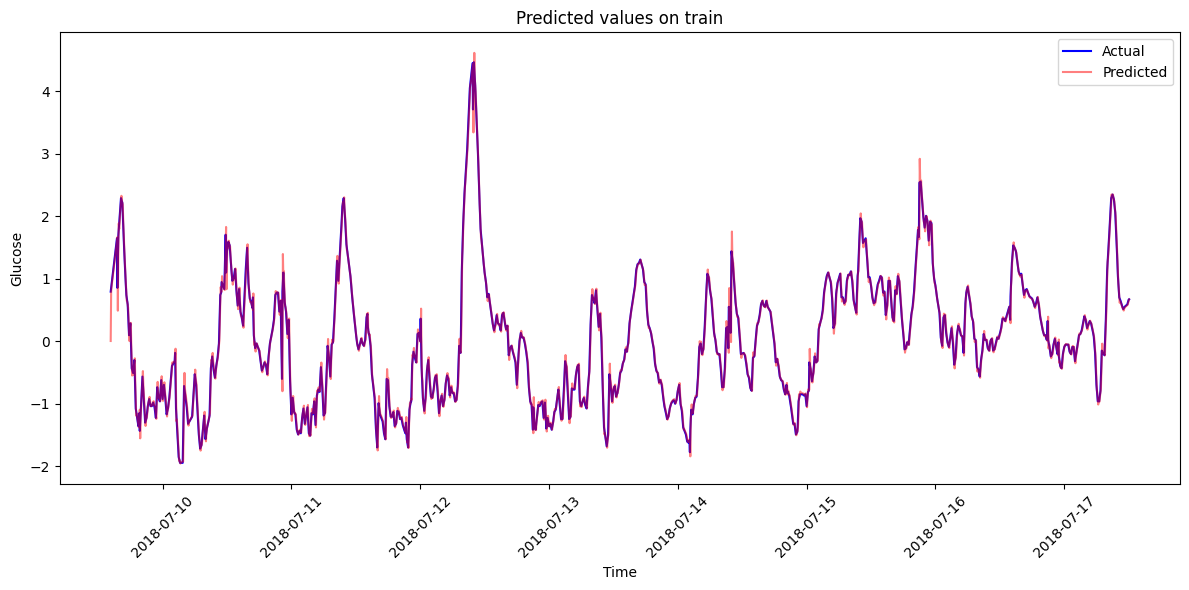

In [273]:
plt.figure(figsize=(12, 6))
plt.plot(train['time'], endog, label='Actual', color='blue')
plt.plot(train['time'], predictions_train, label='Predicted', color='red', alpha=0.5)
plt.title('Predicted values on train')
plt.xlabel('Time')
plt.ylabel('Glucose')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Qualitative analysis

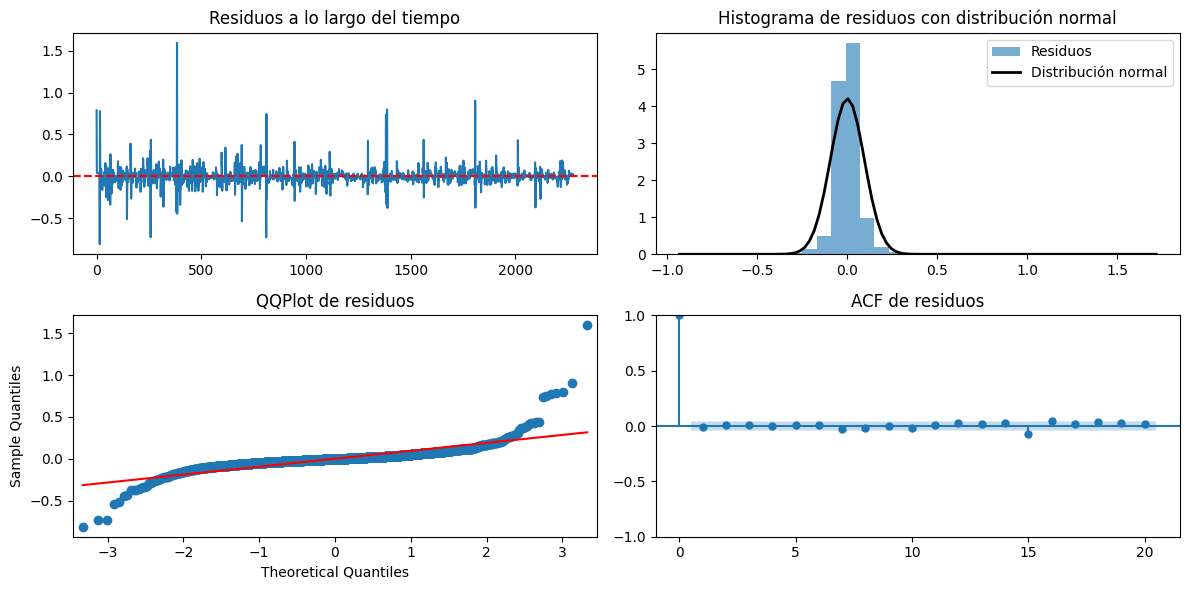

In [274]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(residuals)
plt.title("Residuos a lo largo del tiempo")
plt.axhline(y=0, color='r', linestyle='--')

plt.subplot(2, 2, 2)
plt.hist(residuals, bins=30, density=True, alpha=0.6, label='Residuos')
mu, std = np.mean(residuals), np.std(residuals)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Distribución normal')
plt.title("Histograma de residuos con distribución normal")
plt.legend()

plt.subplot(2, 2, 3)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title("QQPlot de residuos")

plt.subplot(2, 2, 4)
sm.graphics.tsa.plot_acf(residuals, lags=20, alpha=0.05, ax=plt.gca())
plt.title("ACF de residuos")

plt.tight_layout()
plt.show()

### Quantitative analysis 

We Ljung-Box test establish that the residuals are independently distributed as null hypothesis 

In [275]:
lags = np.arange(1, 11, 1)
df_residuals = acorr_ljungbox(residuals, lags)
df_residuals['Lag k'] = np.arange(1, 11)

In [276]:
df_residuals

,lb_stat,lb_pvalue,Lag k
1,0.080339,0.776838,1
2,0.229096,0.891769,2
3,0.436616,0.932579,3
4,0.444845,0.978643,4
5,0.502022,0.992049,5
6,0.565185,0.996952,6
7,2.574389,0.921392,7
8,3.026783,0.932666,8
9,3.026983,0.963216,9
10,3.441733,0.969040,10


## Test

In [277]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2278
Model:               SARIMAX(2, 0, 3)   Log Likelihood                2163.920
Date:                Sun, 30 Nov 2025   AIC                          -4313.839
Time:                        22:41:00   BIC                          -4273.722
Sample:                             0   HQIC                         -4299.206
                               - 2278                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0009      0.005      0.195      0.845      -0.008       0.010
ar.L1          1.8621      0.041     45.715      0.000       1.782       1.942
ar.L2         -0.8663      0.040    -21.504      0.0

In [278]:
exog_test = scaler_exog.transform(test[exog_variable].values.reshape(-1, 1))

In [279]:
test_predicted = best_model.predict(
    start=len(train), 
    end=len(train)+len(test)-1,
    exog=exog_test
)

Plot predictions 

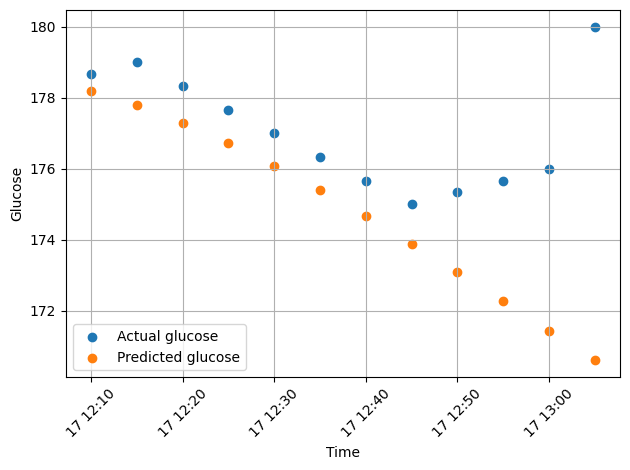

In [280]:
time_test = test['time'][-horizon:]
plt.scatter(time_test, test['glucose'], label='Actual glucose')
plt.scatter(time_test, scaler_endog.inverse_transform(test_predicted.reshape(-1,1)), label='Predicted glucose')
plt.xlabel('Time')
plt.ylabel('Glucose')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.grid()
plt.ticklabel_format()
plt.show()
